Saved: paper_figures_final\qualitative_72h_core_models.png
Saved: paper_figures_final\qualitative_72h_core_models.pdf


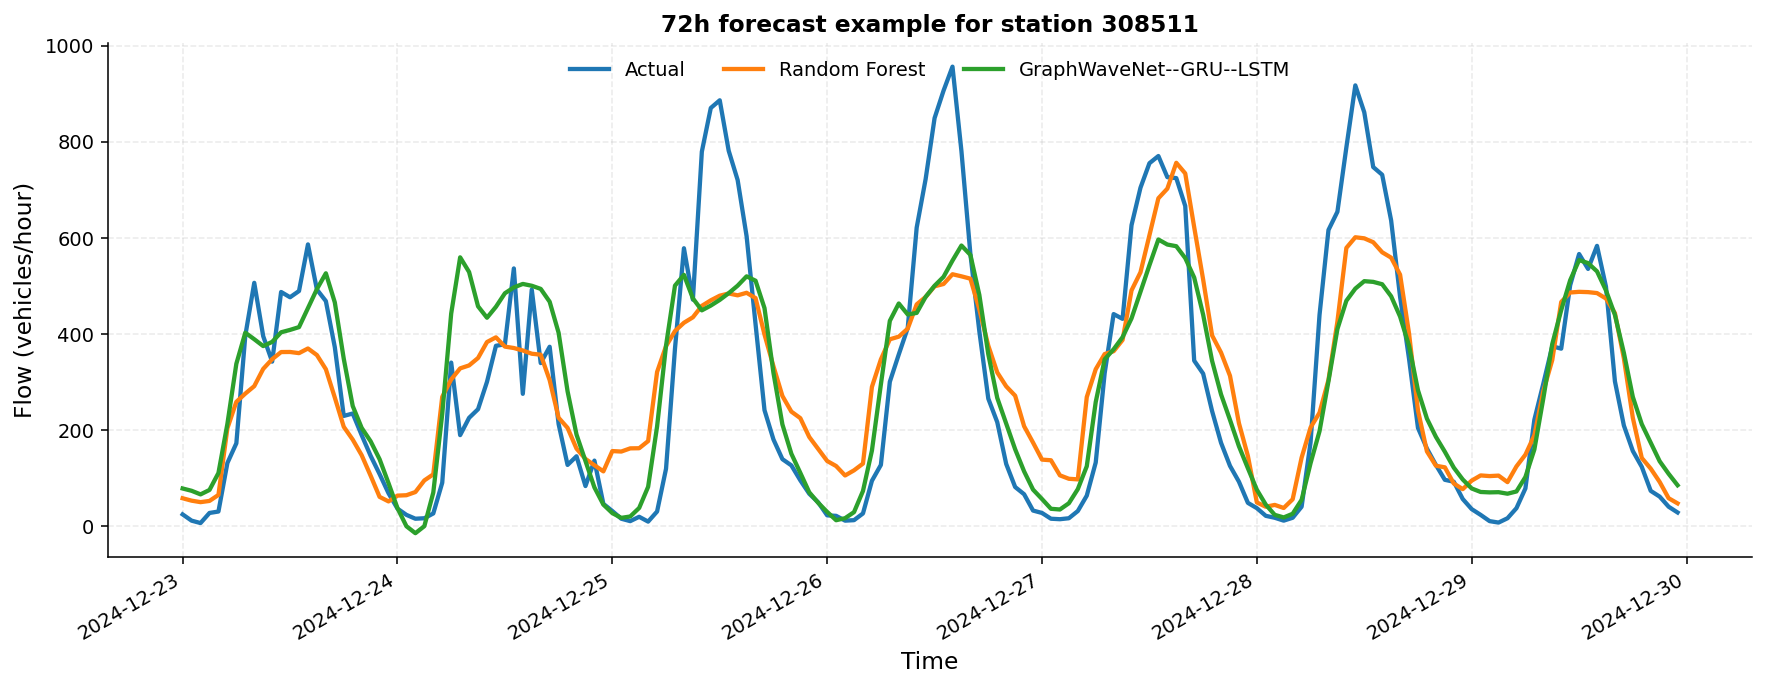

Saved plotted data CSV.


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1) FILE PATHS
# ============================================================
RF_CSV = Path("C:\\Users\\attafuro\\Downloads\\test_pred_true_selected_horizons-random forest.csv")
PROP_XLSX = Path("C:\\Users\\attafuro\\Downloads\\test_pred_true_selected_horizons- Graphwavenet-GRU-LSTM.xlsx")


# ============================================================
# 2) USER SETTINGS
# ============================================================
station_id = "308511"          # Change if needed
target_horizon = 72             # Choose from: 12, 24, 48, 72
start_date = "2024-12-23"
end_date = "2024-12-29 23:59:59"

output_dir = Path("paper_figures_final")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3) PUBLICATION-STYLE PLOT SETTINGS
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 400,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 2.2,
})


def save_figure(fig, stem: str) -> None:
    png_path = output_dir / f"{stem}.png"
    pdf_path = output_dir / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# ============================================================
# 4) LOAD RANDOM FOREST CSV
# Expected columns:
# timestamp, station, horizon_h, y_true, y_pred
# ============================================================
rf = pd.read_csv(RF_CSV)
rf["timestamp"] = pd.to_datetime(rf["timestamp"])
rf["station"] = rf["station"].astype(str)

required_rf_cols = {"timestamp", "station", "horizon_h", "y_true", "y_pred"}
missing_rf_cols = required_rf_cols - set(rf.columns)
if missing_rf_cols:
    raise ValueError(f"Random Forest CSV is missing columns: {missing_rf_cols}")


# ============================================================
# 5) LOAD PROPOSED MODEL EXCEL FILE
# Expected sheet names:
# pred_h12, true_h12, pred_h24, true_h24, pred_h48, true_h48, pred_h72, true_h72
# ============================================================
pred_sheet = f"pred_h{target_horizon}"
true_sheet = f"true_h{target_horizon}"

prop_pred = pd.read_excel(PROP_XLSX, sheet_name=pred_sheet)
prop_true = pd.read_excel(PROP_XLSX, sheet_name=true_sheet)

# Rename the first column to 'timestamp' in case it has another name
prop_pred = prop_pred.rename(columns={prop_pred.columns[0]: "timestamp"})
prop_true = prop_true.rename(columns={prop_true.columns[0]: "timestamp"})

prop_pred["timestamp"] = pd.to_datetime(prop_pred["timestamp"])
prop_true["timestamp"] = pd.to_datetime(prop_true["timestamp"])

# Convert wide format to long format
prop_pred_long = prop_pred.melt(
    id_vars="timestamp",
    var_name="station",
    value_name="y_pred"
)

prop_true_long = prop_true.melt(
    id_vars="timestamp",
    var_name="station",
    value_name="y_true"
)

prop_pred_long["station"] = prop_pred_long["station"].astype(str)
prop_true_long["station"] = prop_true_long["station"].astype(str)

prop = prop_true_long.merge(
    prop_pred_long,
    on=["timestamp", "station"],
    how="inner"
)

prop["horizon_h"] = target_horizon


# ============================================================
# 6) FILTER TO THE SELECTED STATION, HORIZON, AND DATE RANGE
# ============================================================
start_ts = pd.Timestamp(start_date)
end_ts = pd.Timestamp(end_date)

rf_plot = rf[
    (rf["station"] == station_id) &
    (rf["horizon_h"] == target_horizon) &
    (rf["timestamp"] >= start_ts) &
    (rf["timestamp"] <= end_ts)
].copy()

prop_plot = prop[
    (prop["station"] == station_id) &
    (prop["timestamp"] >= start_ts) &
    (prop["timestamp"] <= end_ts)
].copy()

if rf_plot.empty:
    raise ValueError(
        f"No Random Forest rows found for station={station_id}, "
        f"horizon={target_horizon}, date range=({start_date}, {end_date})."
    )

if prop_plot.empty:
    raise ValueError(
        f"No Proposed-model rows found for station={station_id}, "
        f"horizon={target_horizon}, date range=({start_date}, {end_date})."
    )

rf_plot = rf_plot.sort_values("timestamp")
prop_plot = prop_plot.sort_values("timestamp")


# ============================================================
# 7) ALIGN BOTH MODELS ON COMMON TIMESTAMPS
# ============================================================
common_times = sorted(set(rf_plot["timestamp"]).intersection(set(prop_plot["timestamp"])))
if not common_times:
    raise ValueError("No overlapping timestamps found between Random Forest and Proposed model.")

rf_plot = rf_plot[rf_plot["timestamp"].isin(common_times)].copy()
prop_plot = prop_plot[prop_plot["timestamp"].isin(common_times)].copy()

plot_df = pd.DataFrame({"timestamp": common_times})

plot_df = plot_df.merge(
    prop_plot[["timestamp", "y_true"]].drop_duplicates(),
    on="timestamp",
    how="left"
)

plot_df = plot_df.merge(
    rf_plot[["timestamp", "y_pred"]].rename(columns={"y_pred": "rf_pred"}),
    on="timestamp",
    how="left"
)

plot_df = plot_df.merge(
    prop_plot[["timestamp", "y_pred"]].rename(columns={"y_pred": "prop_pred"}),
    on="timestamp",
    how="left"
)


# ============================================================
# 8) PLOT: ACTUAL vs RANDOM FOREST vs PROPOSED MODEL
# ============================================================
fig, ax = plt.subplots(figsize=(12.5, 4.8), constrained_layout=True)

ax.plot(plot_df["timestamp"], plot_df["y_true"], label="Actual")
ax.plot(plot_df["timestamp"], plot_df["rf_pred"], label="Random Forest")
ax.plot(plot_df["timestamp"], plot_df["prop_pred"], label="GraphWaveNet--GRU--LSTM")

ax.set_title(f"{target_horizon}h forecast example for station {station_id}")
ax.set_xlabel("Time")
ax.set_ylabel("Flow (vehicles/hour)")
ax.legend(frameon=False, ncol=3, loc="upper center")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

save_figure(fig, "qualitative_72h_core_models")
plt.show()


# ============================================================
# 9) OPTIONAL: SAVE THE DATA USED FOR THE FIGURE
# ============================================================
plot_df.to_csv(output_dir / "qualitative_72h_core_models_data.csv", index=False)
print("Saved plotted data CSV.")